A. Basic Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [ ]:
# Load the dataset into a DataFrame and display the number of rows and columns (1 pt)
df= pd.read_csv('hrdata.csv')
rows,cols=df.shape
print(f"number of rows: {rows}")
print(f"number of columns: {cols}")

number of rows: 21287
number of columns: 18


In [ ]:
#Use describe() to show summary statistics of numerical columns (1 pt)
df.describe()

,Unnamed: 0,rec_num,enrollee_id,city_development_index,training_hours,target,city_development_matrics
count,21287.000000,21287.000000,21287.000000,21287.000000,21287.000000,19158.000000,21287.000000
mean,10643.000000,10644.000000,16873.983652,0.828462,65.328510,0.249348,8.284615
std,6145.171926,6145.171926,9612.131237,0.123537,60.075201,0.432647,1.235365
min,0.000000,1.000000,1.000000,0.448000,1.000000,0.000000,4.480000
25%,5321.500000,5322.500000,8554.500000,0.739000,23.000000,0.000000,7.390000
50%,10643.000000,10644.000000,16967.000000,0.903000,47.000000,0.000000,9.030000
75%,15964.500000,15965.500000,25161.500000,0.920000,88.000000,0.000000,9.200000
max,21286.000000,21287.000000,33380.000000,0.949000,336.000000,1.000000,9.490000


In [ ]:
df["rec_num"].head(10)

,rec_num
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
df["rec_num"].tail(10)

,rec_num
21277,21278
21278,21279
21279,21280
21280,21281
21281,21282
21282,21283
21283,21284
21284,21285
21285,21286
21286,21287


In [ ]:
df["Unnamed: 0"].head(10)

,Unnamed: 0
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [ ]:
df["Unnamed: 0"].tail(10)

,Unnamed: 0
21277,21277
21278,21278
21279,21279
21280,21280
21281,21281
21282,21282
21283,21283
21284,21284
21285,21285
21286,21286


In [ ]:
df["enrollee_id"].head(10)

,enrollee_id
0,8949
1,29725
2,11561
3,33241
4,666
5,21651
6,28806
7,402
8,27107
9,699


#Explain any interesting or useful statistics you observe:

This table shows us a few important ideas:

1. Missing values in target (there are a total of 21287 rows but target's count only displays 19158), which we will indicate further analysis will be needed to determine if we will need to handle missing values in a certain manner.

2. After a little more analysis (looking more closely at the first few and last few data points), we see that variables "Unnamed: 0", "rec_num", and "enrollee_id" are all either indexing numbers or a series of numbers used to uniquely identify a candidate. The indexing numbers need to be further analyzed; however, since they are just numbers that increase sequentially, they don't provide much insight, so we may remove them from the dataset. And while "enrollee_id" represents each employee ID number, it doesn't carry any numeric meaning; therefore is not needed for the modeling process as a predictive feature but should be kept in the dataset for identifying purposes.

3. The variable "training_hours" is right skewed as the mean (65) is greater than the median (47), we know that there will be a tail as the maximum is 336. (The long tail also suggests there may be outliers, so we might have to analyize this further).

In [ ]:
#Display the first 5 and last 5 rows of the DataFrame
df.head(5)

,Unnamed: 0,rec_num,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,state,city_development_matrics
0,0,1,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,CA,9.20
1,1,2,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,CA,7.76
2,2,3,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,CA,6.24
3,3,4,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,CA,7.89
4,4,5,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,CA,7.67


In [ ]:
df.tail(5)

,Unnamed: 0,rec_num,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,state,city_development_matrics
21282,21282,21283,1289,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15,NaN,CA,9.20
21283,21283,21284,195,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30,NaN,CA,8.97
21284,21284,21285,31762,city_100,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18,NaN,CA,8.87
21285,21285,21286,7873,city_102,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84,NaN,CA,8.04
21286,21286,21287,12215,city_102,0.804,Male,Has relevent experience,no_enrollment,Masters,STEM,15,10000+,Pvt Ltd,2,11,NaN,CA,8.04


In [ ]:
#List all numerical columns
numeric_features=df.select_dtypes(include=[np.number])
numeric_features.columns

Index(['Unnamed: 0', 'rec_num', 'enrollee_id', 'city_development_index',
       'training_hours', 'target', 'city_development_matrics'],
      dtype='object')

In [ ]:
#List all categorical columns
categorical_features=df.select_dtypes(include=["object"]).columns
categorical_features

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job', 'state'],
      dtype='object')

B. Missing Value Analysis

In [ ]:
#Display column-wise count of missing values in descending order
missing_count = df.isna().sum().sort_values(ascending=False)
missing_count

,0
company_type,6774
company_size,6560
gender,5016
major_discipline,3125
target,2129
education_level,512
last_new_job,463
enrolled_university,417
experience,70
Unnamed: 0,0


In [ ]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent

,0
company_type,31.822239
company_size,30.816931
gender,23.563677
major_discipline,14.680321
target,10.001409
education_level,2.405224
last_new_job,2.175036
enrolled_university,1.958942
experience,0.328839
Unnamed: 0,0.000000


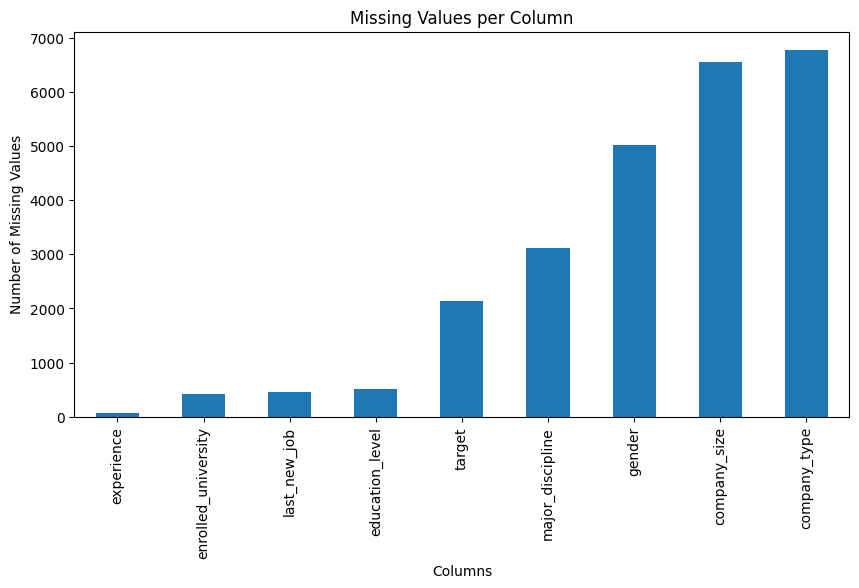

In [ ]:
missing_only = missing_count[missing_count > 0].sort_values()
plt.figure(figsize=(10, 5))
missing_only.plot(kind='bar')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.title('Missing Values per Column')
plt.show()

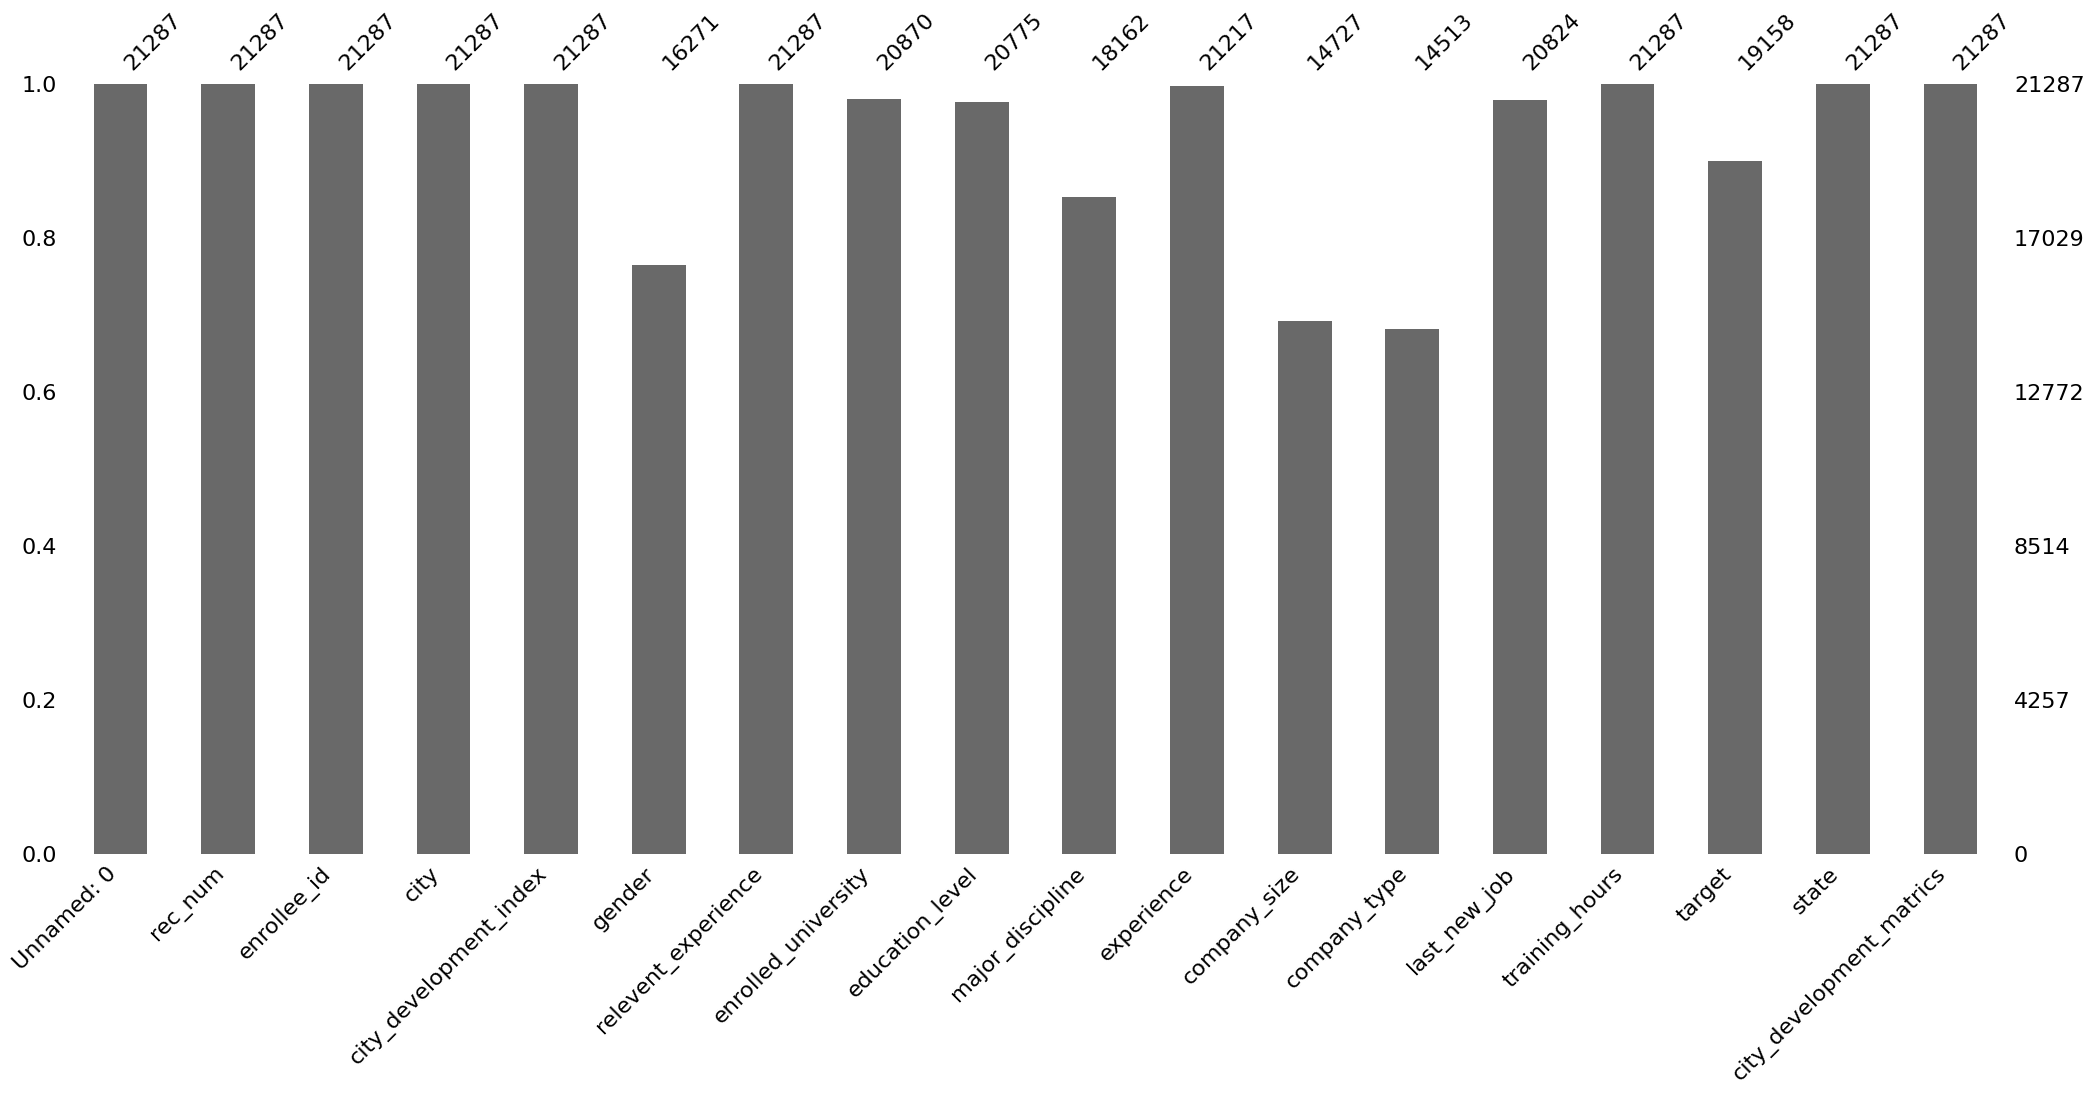

In [ ]:
msno.bar(df)
plt.show()

In this bar plot we can see short and tall bars, the shorter a bar is the more missing values it contains meaning it have fewer nonmissing data available while the taller bars represent the categories that have more data available to be used.

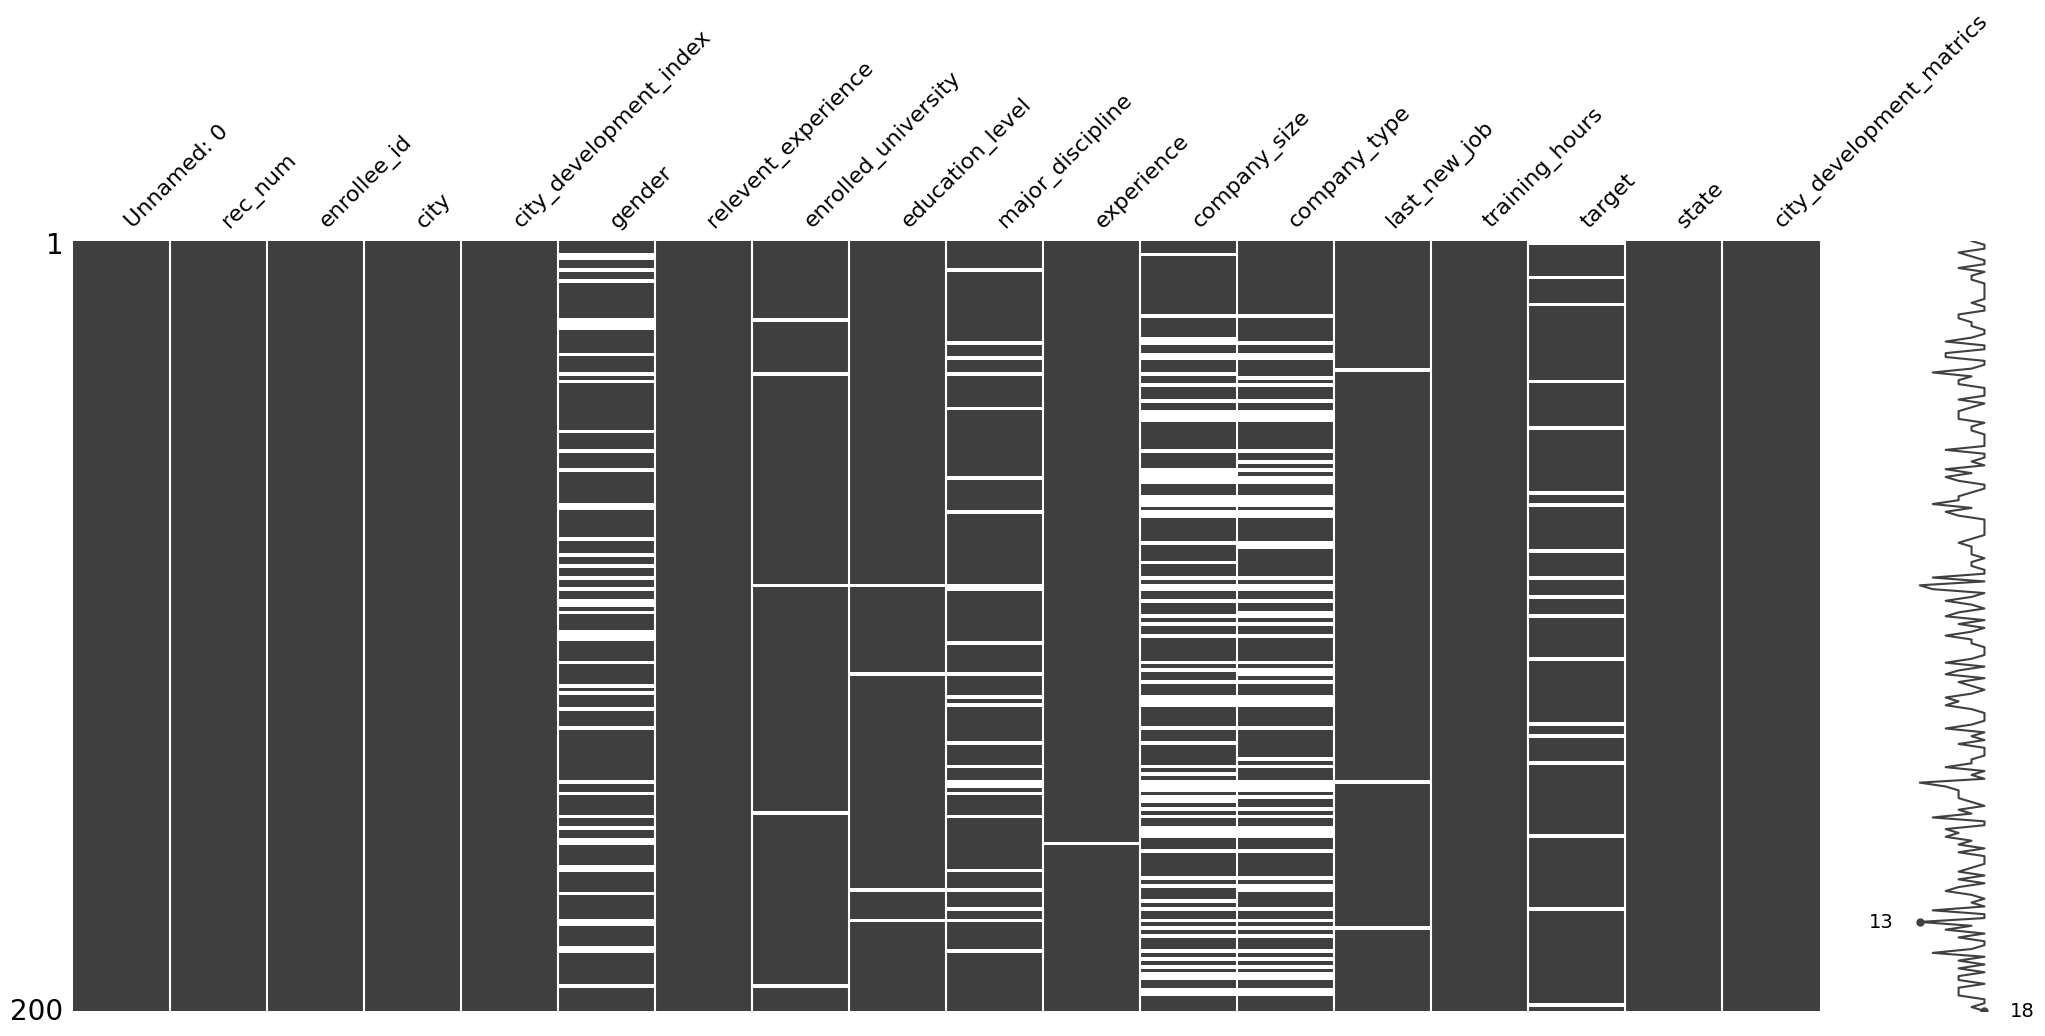

In [ ]:
msno.matrix(df.sample(200))
plt.show()


In this Matrix plot, we can see some patterns of missingness in specific columns rather than entire rows. Some variables have few to no missing values, while others exhibit frequent missingness. This pattern of missingness might be due to data collection errors rather than random error, as it exhibits a vertical structure.

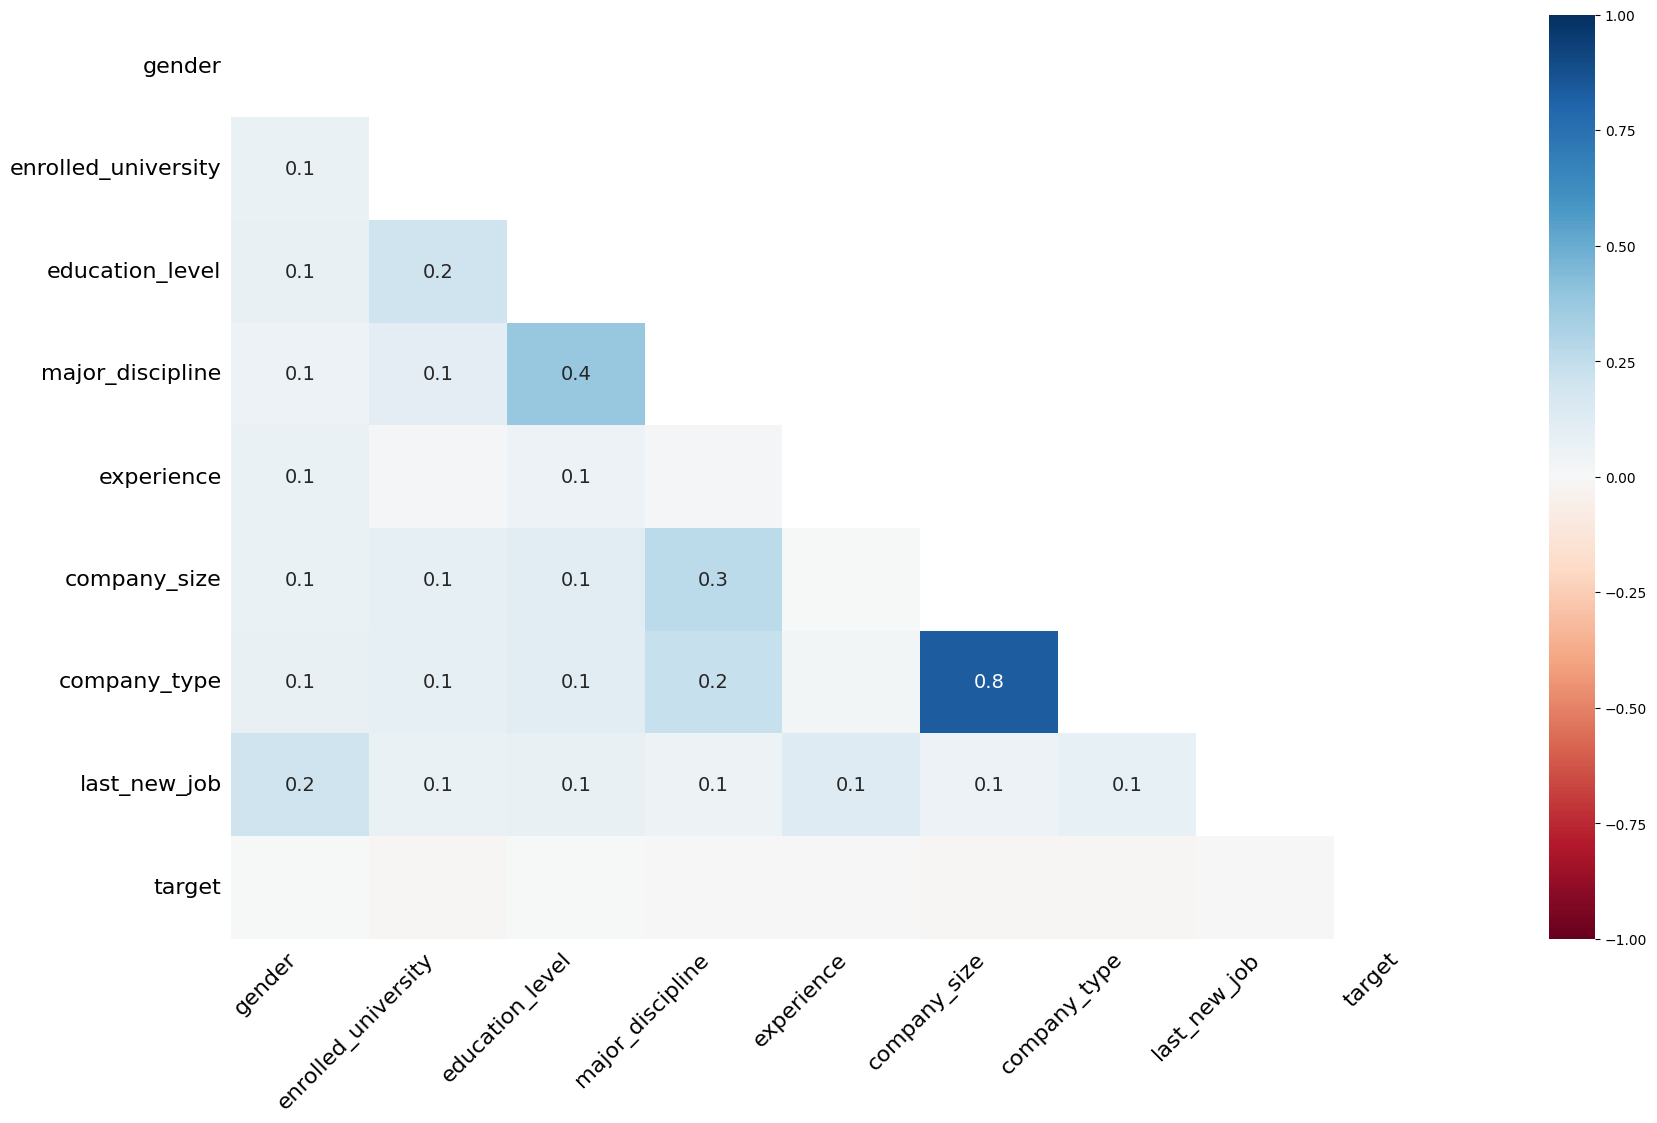

In [ ]:
msno.heatmap(df)
plt.show()



In this correlation heatmap, there are some strong correlations between some missing values in some of the variables. One relationship that stood out is the relationship between company_size and company_type, as the missingness indicates that these features might be missing together. This strongly suggests that missingness may come from errors in data collection rather than random error. Other variables show very weak or almost no correlation with each other; this implies large independent missingness.


C. Understanding Categorical Attributes

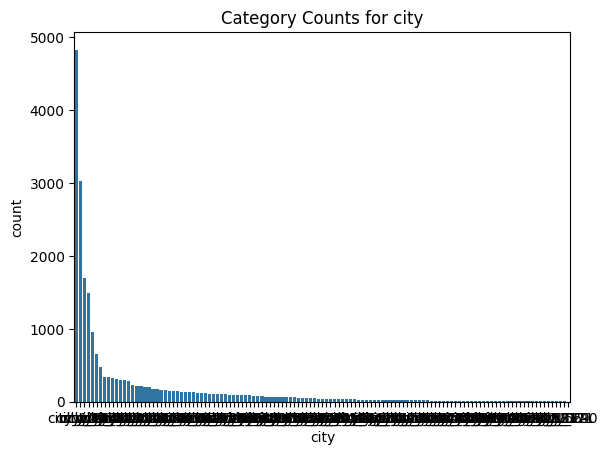

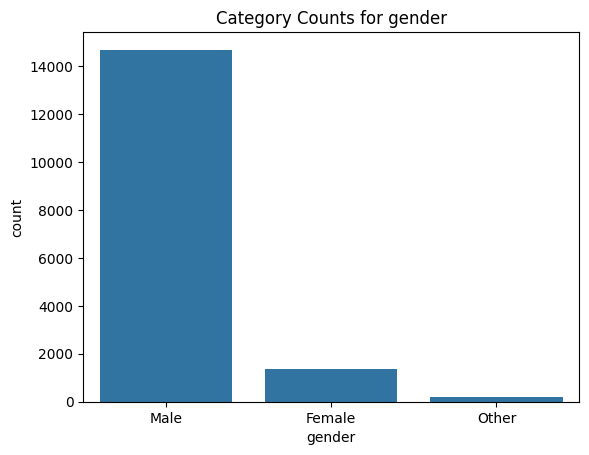

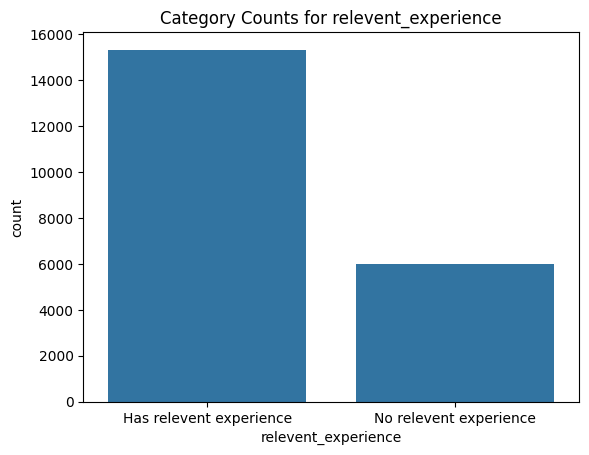

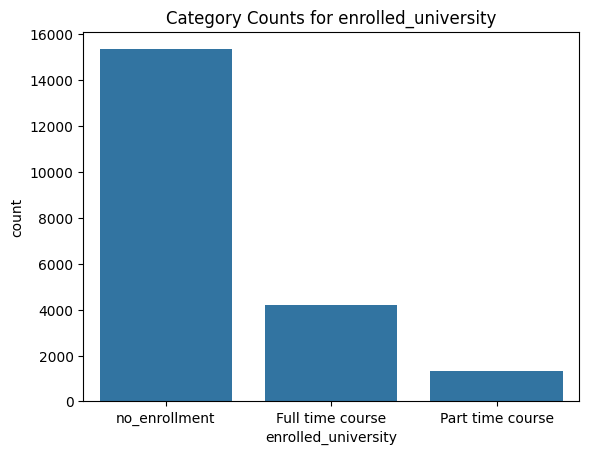

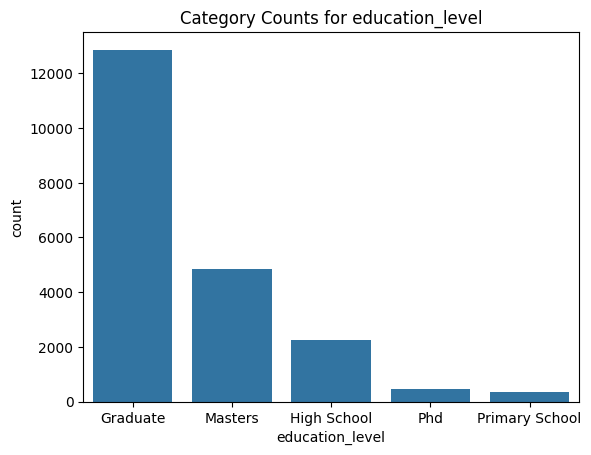

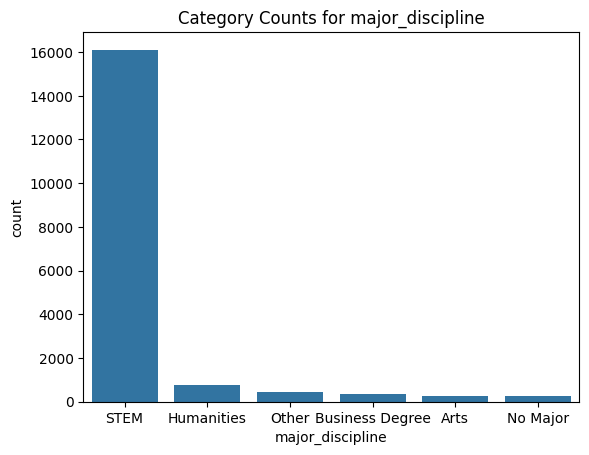

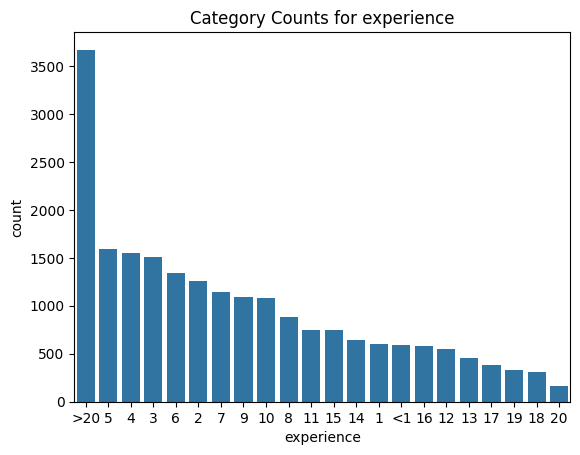

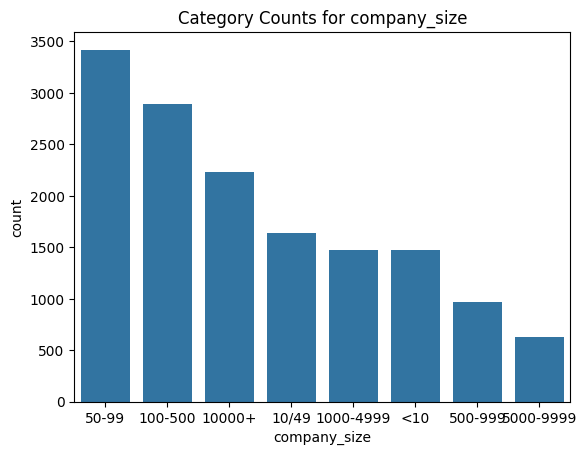

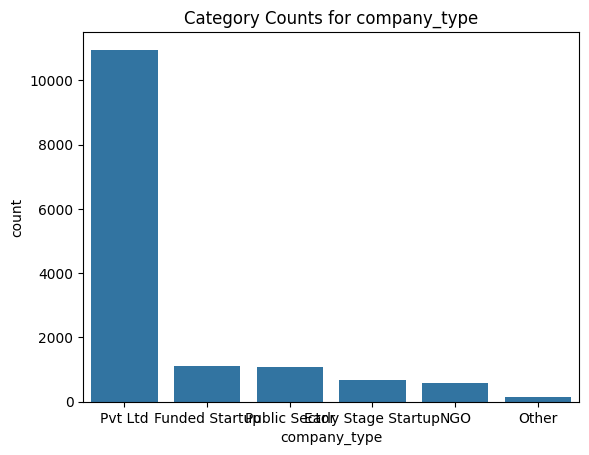

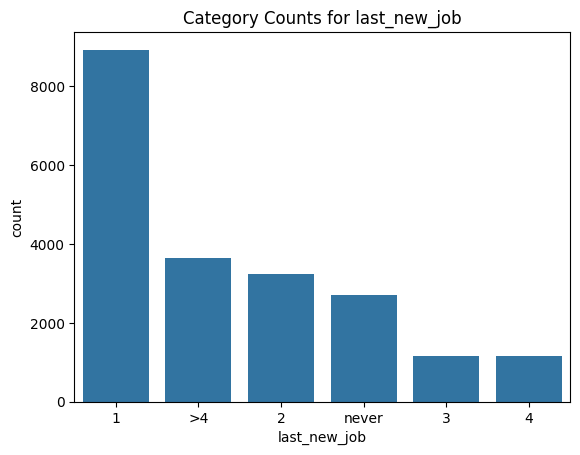

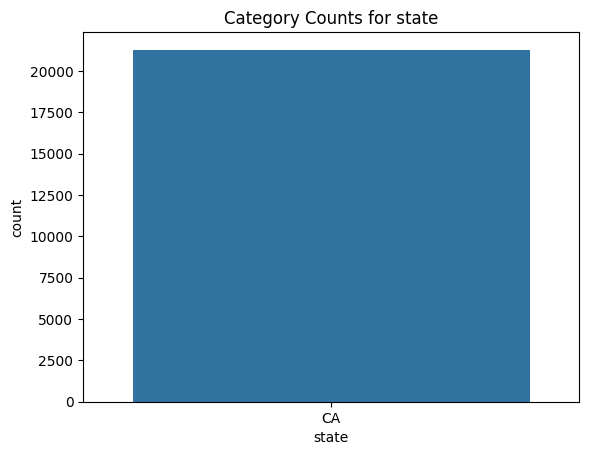

In [ ]:

for col in categorical_features:
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.title(f'Category Counts for {col}')
    plt.show()

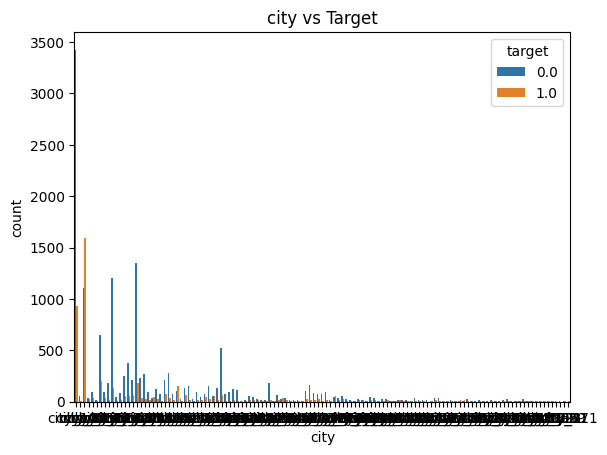

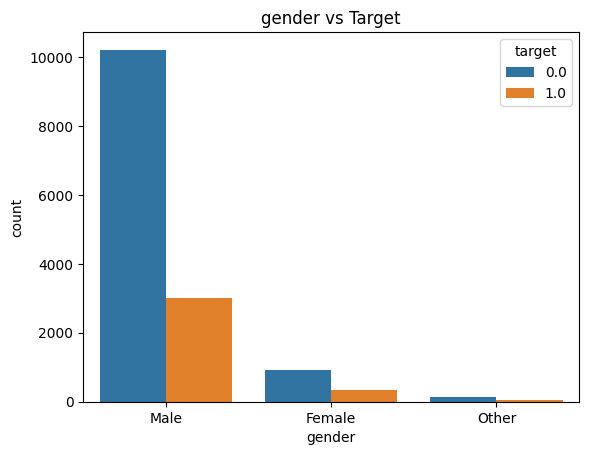

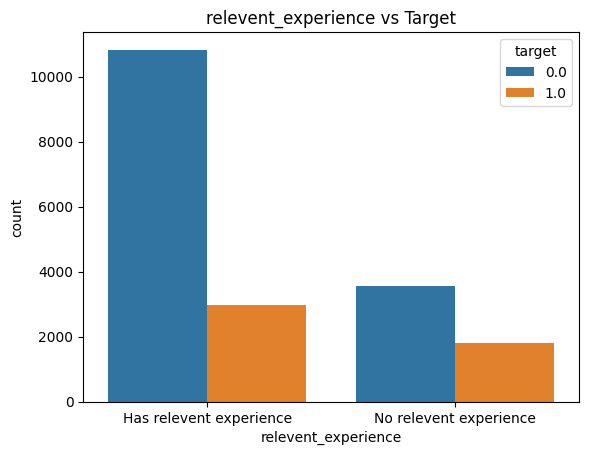

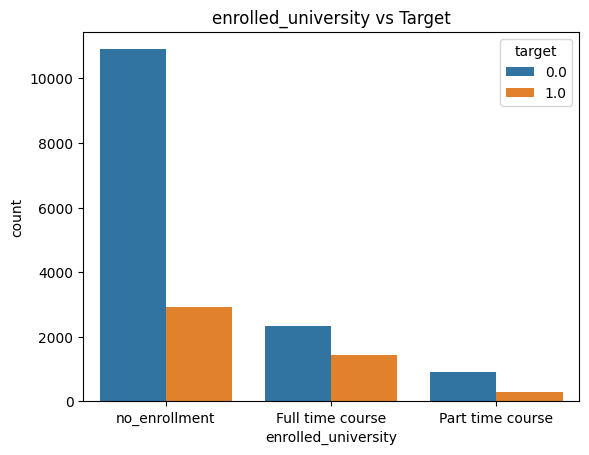

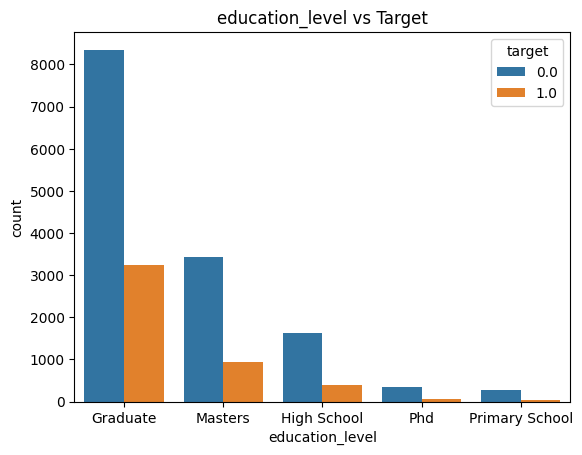

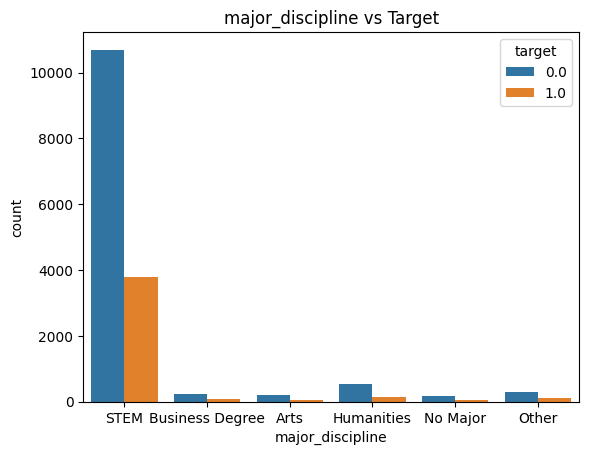

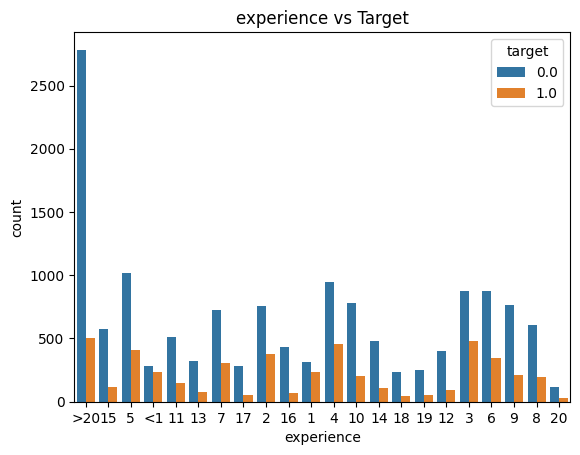

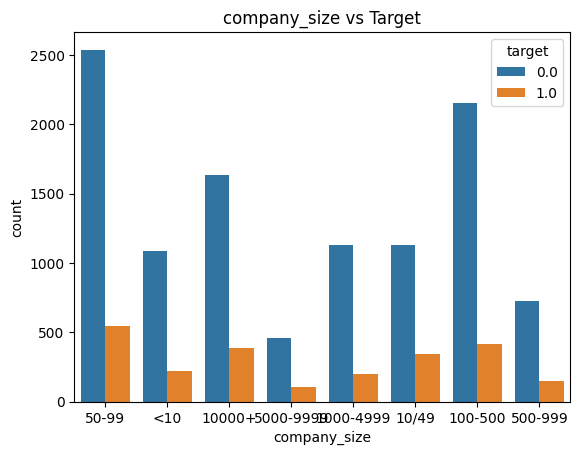

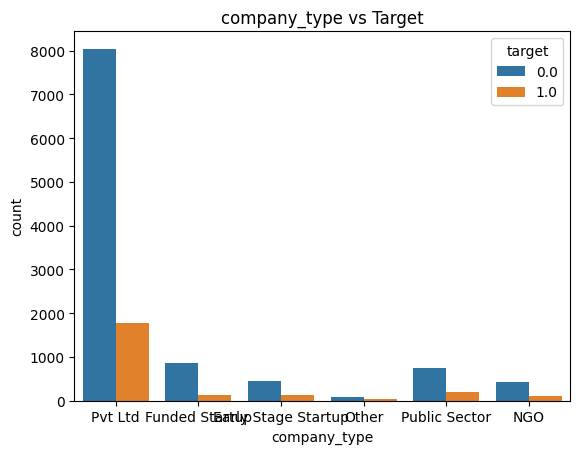

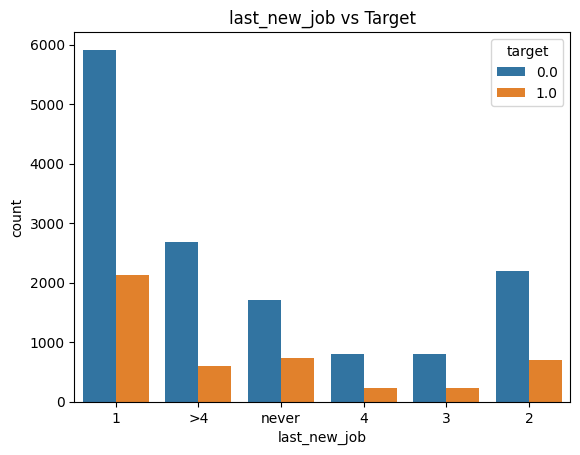

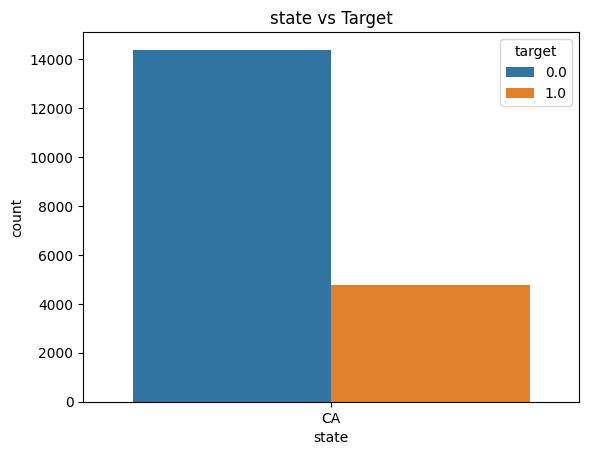

In [ ]:
for col in categorical_features:
    sns.countplot(
        data=df,
        x=col,
        hue='target'
    )
    plt.title(f'{col} vs Target')
    plt.show()


#####interpretation: After constructing bar plots for each category and a countplot for the feature against the target variable we can see many issues in our dataset. The biggest issue that stood out is  imbalance, the dataset seems to have an abundance of male observations but a minority with female and other observations.

##### another issue we  see is how few obervations there are with many cities, showing cardinality, to fix this we can consider removing city all together or grouping all the rare cities with not many observations together.

##### Another observation I made is that most individuals are not enrolled in a university, to help settle this imbalance between not enrolled, part time and full times students we can merge full time and part time together to create not enrolled vs enrolled in university. This will reduce sparsity and simplify the feature.

##### Another two observations we see if that for major discipline STEM overwhelmingly dominates the dataset compared to non-stem categories, to help with this imbalance we can combine the features and turn it into STEM and nonSTEM major discipline. The other observation I made is the education level has some imbalance as well. Graduates and masters seems to dominate the dataset while PhD and primary school has smaller counts, to help this imbalance we can combine the rare categories like PhD, primary school and other together.

##### Another observation I made is that we only can see the state CA in out observations only, we don't see other states so it would be ideal to remove this feature as it provides no real insights to our data.

##### We also see that across almost all the features with target=0 dominating target =1 has class imbalance. To fix this we can use undersampling or oversampling.



D. Understanding Numerical Attributes

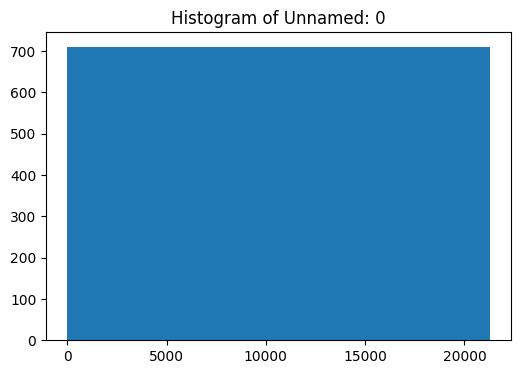

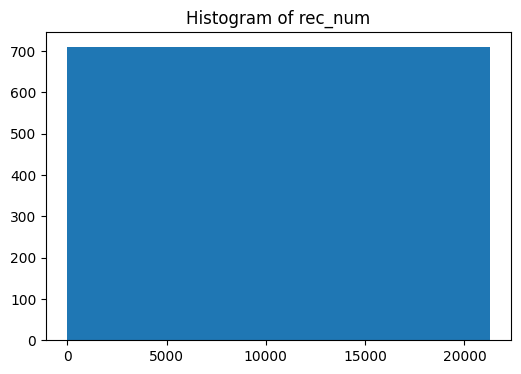

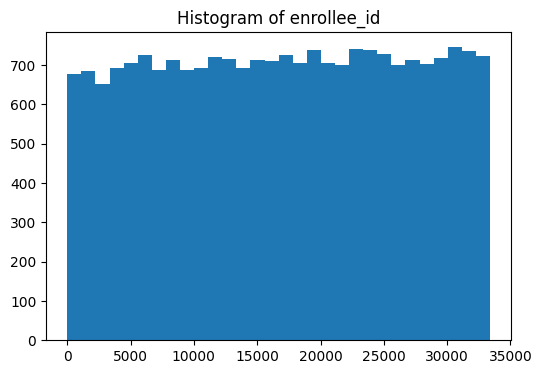

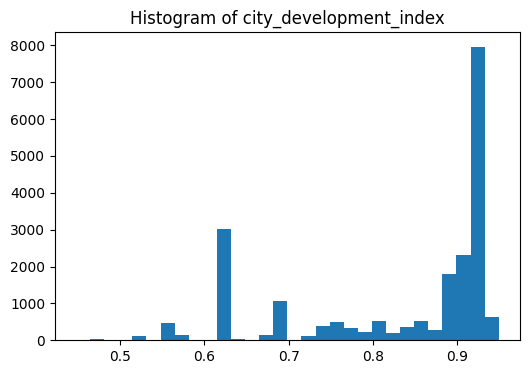

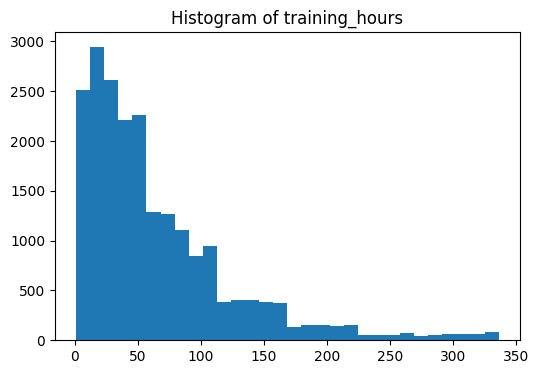

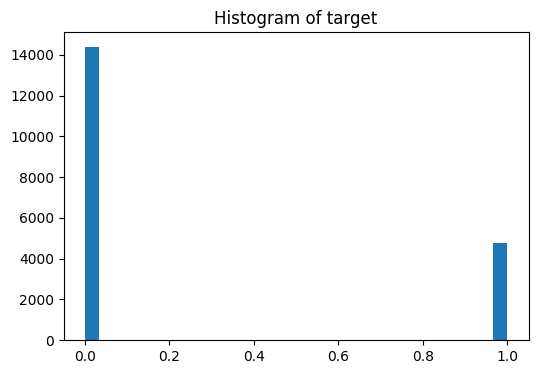

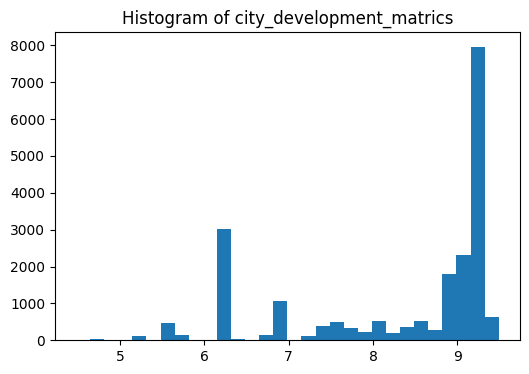

In [ ]:
for col in numeric_features.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histogram of {col}')
    plt.show()


/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


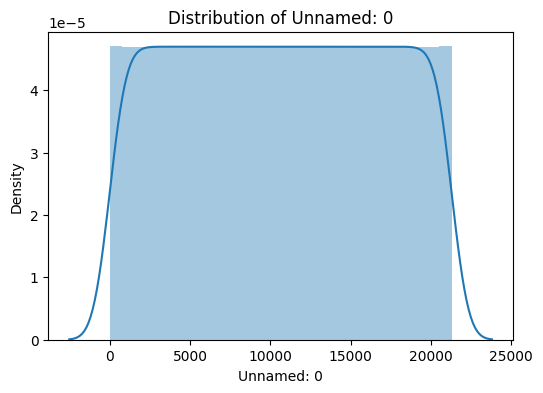

/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


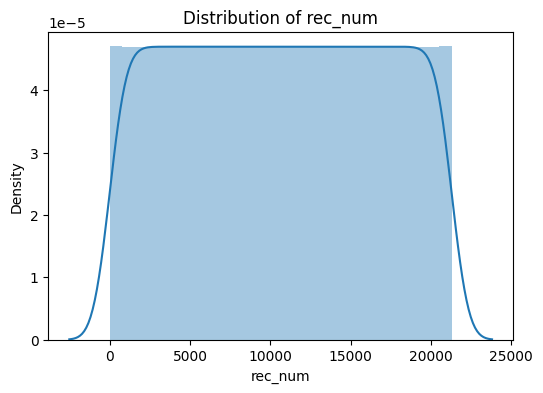

/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


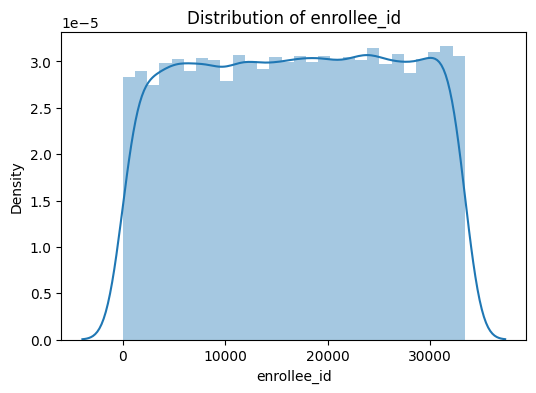

/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


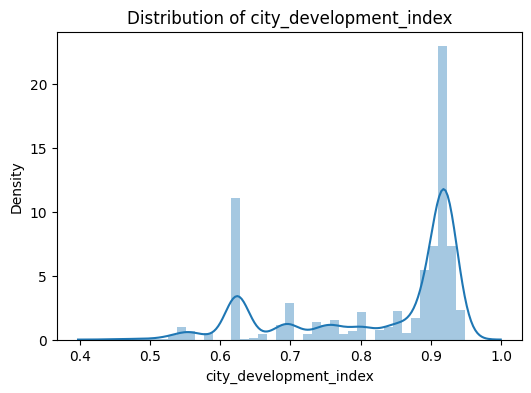

/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


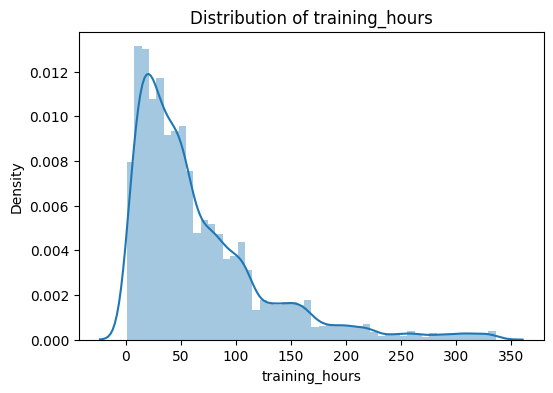

/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


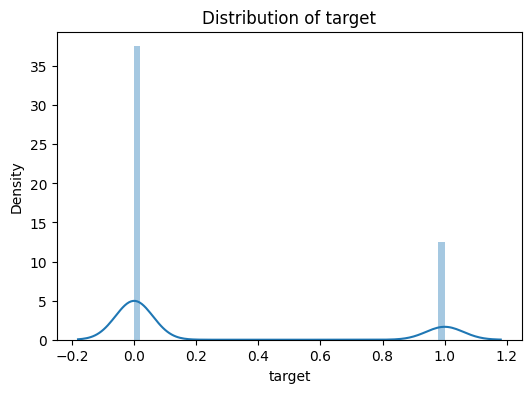

/tmp/ipython-input-2525920068.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col].dropna(), kde=True)


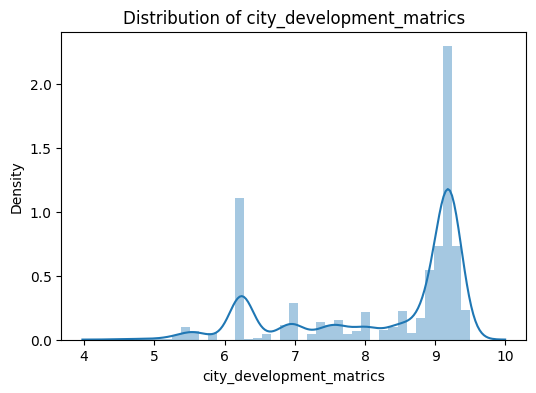

In [ ]:
for col in numeric_features.columns:
    plt.figure(figsize=(6,4))
    sns.distplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#####The variables Unnamed: 0, rec_num, and enrollee_id are all almost uniformly distributed across their values. Since these variables act like identifiers rather than providing meaningful insight into numeric features, we should remove them from the dataset before modeling.
#####I also observed some skewness in certain variables, such as a left skew in city_development_index, with most of the values gathering near 0.9. This shows clustering as well. This indicates that most of the observations come from high-development cities, and not many come from low-development cities. Another skewed distribution we see is training_hours, which has a right skew. Most individuals have low training hours, while a few individuals have very high values. This suggests there might be outliers, or we may need to transform this variable to improve model performance.
#####One last observation is that the target variable shows some imbalance, with most observations stemming from 0 rather than 1. This, combined with the past findings, confirms the need for under/oversampling.

E. Correlation Analysis

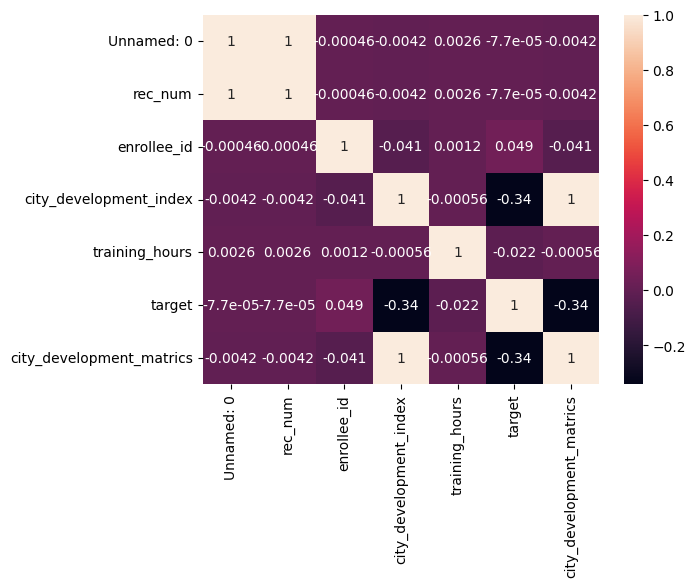

In [ ]:
corr= df[numeric_features.columns].corr()
sns.heatmap(corr, annot=True)
plt.show()


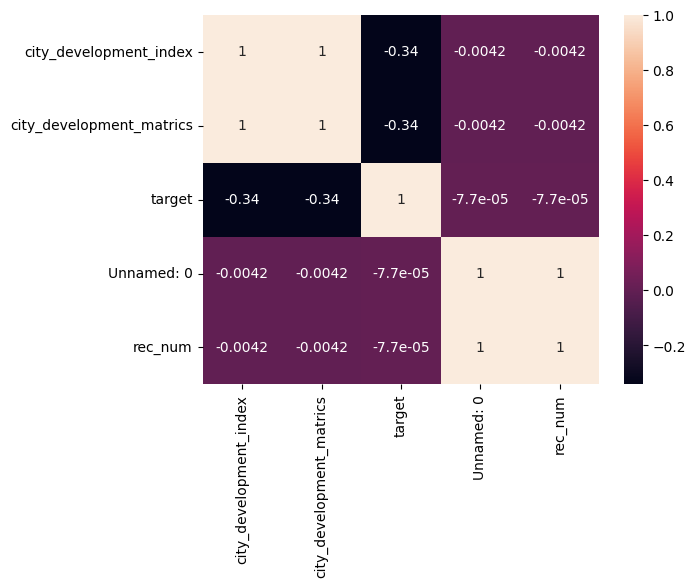

In [ ]:
focused=['city_development_index','city_development_matrics', 'target', 'Unnamed: 0', 'rec_num']

corr= df[focused].corr()
sns.heatmap(corr, annot=True)
plt.show()

In this correlation heatmap, we observe a few things:

1. We see that both city_development_index and city_development_matrics have a correlation of 1.00, which means that they most likely represent the same information. To avoid redundancy and avoid increasing  variance, we should remove one variable and keep only one of them.

2. Another observation made is that both Unnamed: 0 and rec_num also have a correlation of 1.00. Since they are perfectly correlated, we should remove one of the variables to avoid redundancy.

3. Another interesting observation I saw is a correlation of -0.34 between target and city_development_index. This moderately negative correlation suggests that the more developed a city is, the lower the probability of the target equaling 1. This could mean that this feature might be predictive, meaning we should examine this correlation more closely.

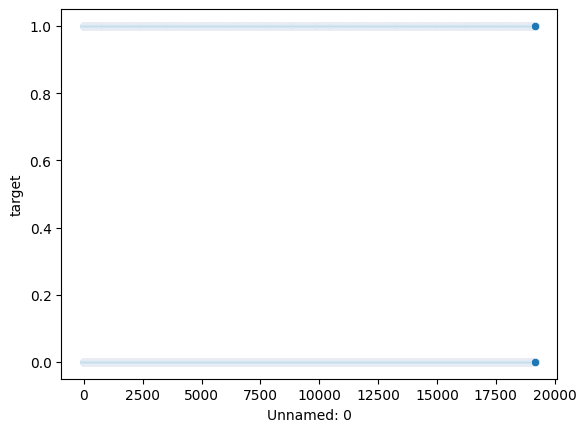

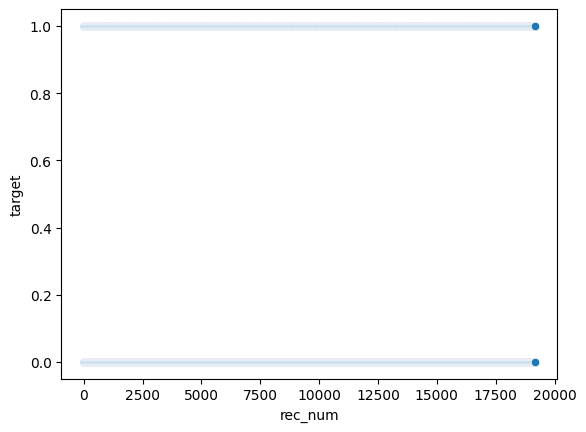

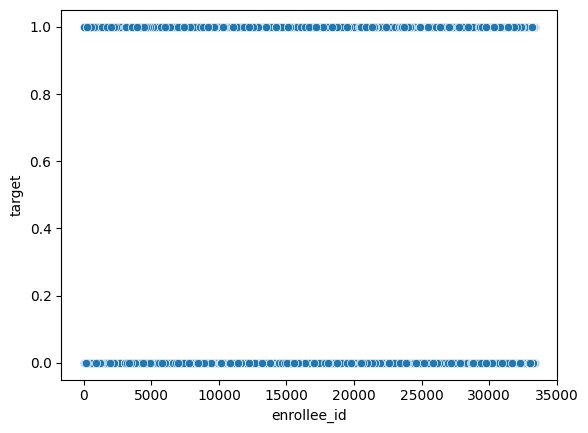

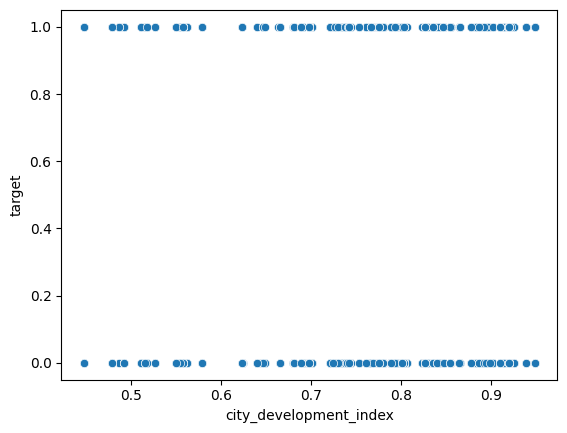

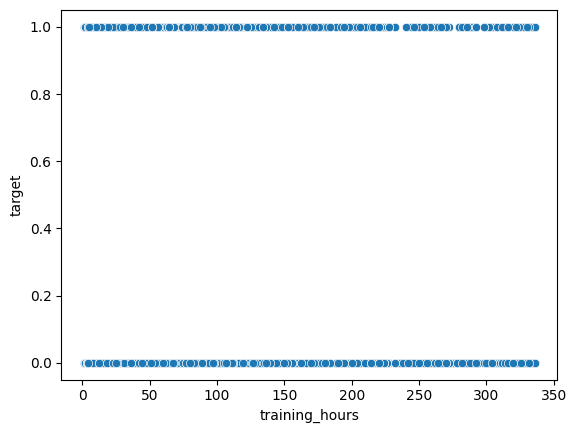

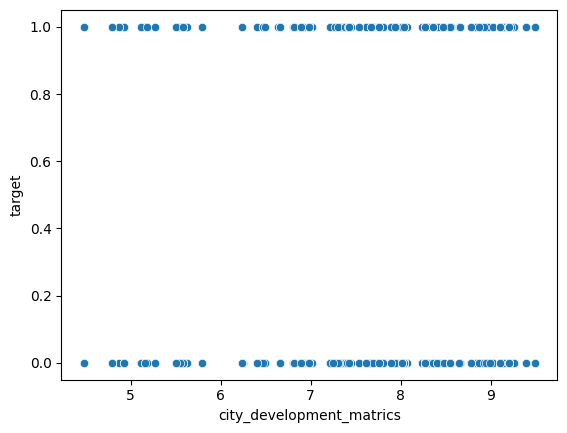

In [ ]:
for col in numeric_features.columns:
  if col!='target':
    sns.scatterplot(data=df, x=col, y='target')
    plt.show()

##### These scatter plots show that most numeric features don't have a clear seperation between target = 0  and target = 1, this would make it harder for the model to classify since the feature doesn't seperate classes well. This suggests that we may need to do some feature engineering (either transform or combine features) to help with performance.

Another observation made is the variables Unnamed: 0, rec_num, enrollee_id are all identifier variables and should be removed

City_development_index and city_development_matrics are perfectly correlated one of the variables should be removed to avoid redundancy

The training hours variable shows that there is a wide range of values and has a strong right skew which indicates it should be investigated further and will possible need some feature engineering done like transformations to help modeling.

######Possible next steps:

1. Remove Unnamed: 0, rec_num, enrollee_id
2. drop one of the perfectly correlated features
3. Transform the skewed variable like training_hours
4. Since Target has class imbalance, we should apply under/over sampling to fix the imbalance
5. Use feature selection to identify any useful predictors

F. Outliers

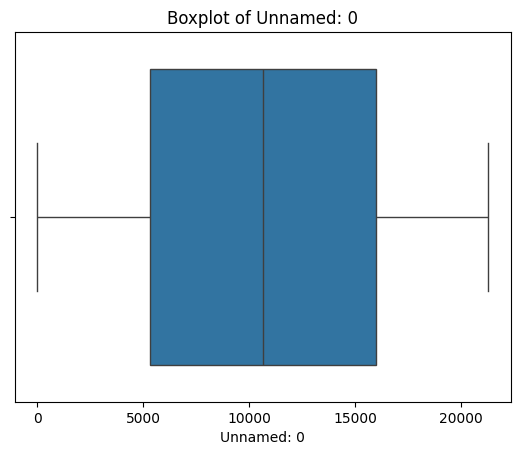

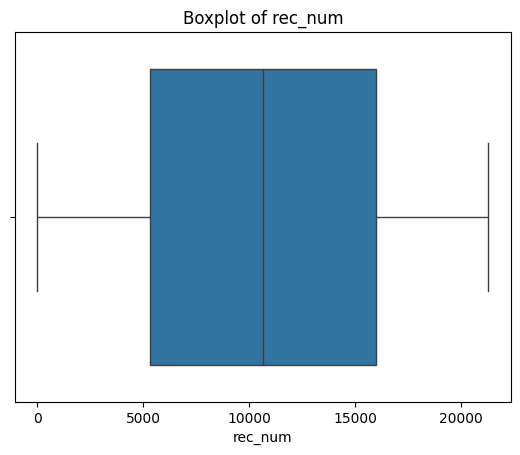

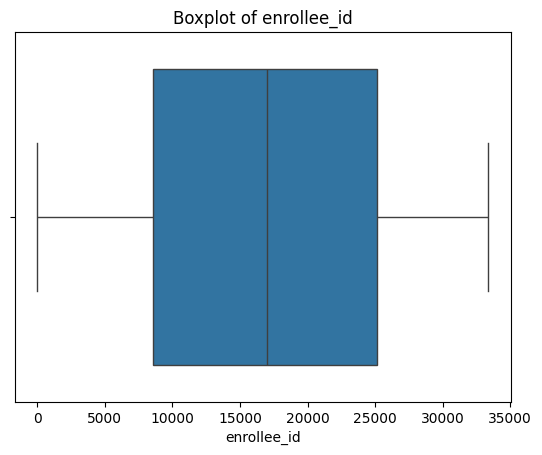

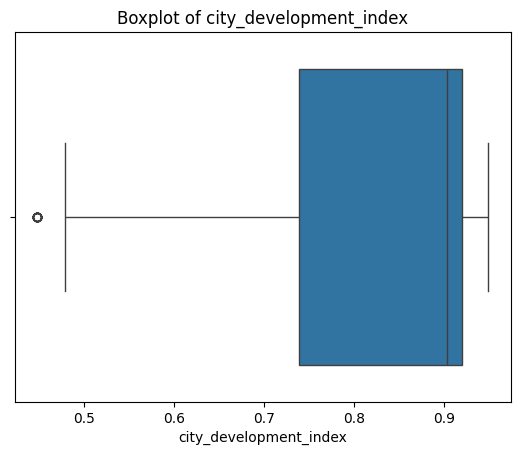

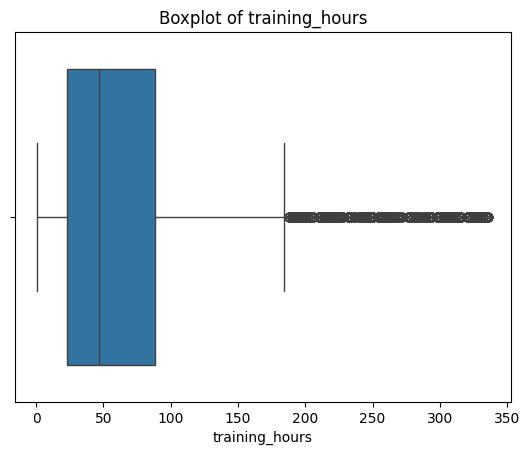

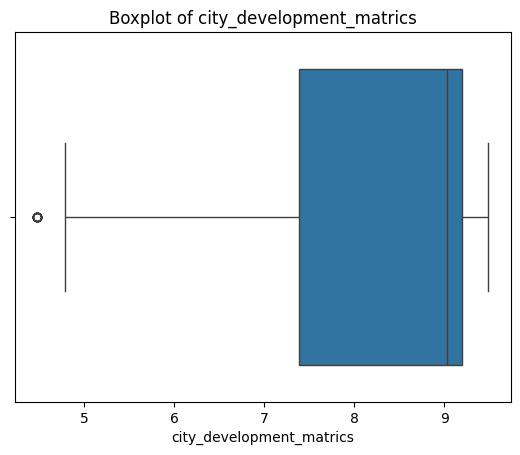

In [ ]:
#Use boxplots or other appropriate methods to detect outliers
for col in numeric_features.columns:
  if col!='target': #skip-> binary
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


#####This outlier detection highlights a few observations. We can see that the variables Unnamed: 0, enrollee_id, and rec_num must be removed as they do not show any meaningful insight. They have no meaningful outliers and act as identifiers.

#####The variable training_hours shows many high-value outliers that go beyond the upper whisker. This further provides evidence that the variable is strongly right-skewed and needs feature engineering (transformation) to handle the extreme values and prevent them from influencing model performance.

#####Another observation I made is that the box plots for city_development_index and city_development_matrics have the exact same box plot, which further supports the fact that they are perfectly correlated and one of them should be removed. They both also have a low-value outlier, while the rest of the data clusters around the higher-value range.

G. Experience Categorization

In [ ]:
df['experience'].unique()

array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', nan],
      dtype=object)

In [ ]:
#convert to numeric
df['experience_num']=df['experience'].replace({'<1' :0, '>20':21})

df['experience_num'] = pd.to_numeric(df['experience_num'])

def group_exp(x):
  if pd.isna(x):
    return None
  elif x<=5:
    return 0
  elif x<=15:
    return 1
  else:
    return 2
#save the groupings
df['experience_group']=df['experience_num'].apply(group_exp)


#####The variable experience is catergorized into 3 ordinal categories using domain based binning

0 - low experience
1 - medium experience
2- high experience

I broke it down so that 0-5 years represents low experience, 6-15 years represents medium experience and anything beyond 15 years represent high experience. This grouping helps preserve natural order of experience levels (made by my previous knwledge of industry experience). All the missing values were left as null and return nothing since they do not fit the 3 categories

H. Summary and Discussion

After performing Exploratory Data Analysis, we can make a few conclusions to help polish the data before modeling.

First, identifier variables like Unnamed: 0, rec_num, and enrollee_id should be removed, as they provide no meaningful insight. We will also need to remove either city_development_index or city_development_matrics, as we found that they are perfectly correlated, and to avoid redundancy we should remove one variable. It will also help prevent multicollinearity.

Second, during the categorical analysis, I found high cardinality and class imbalance. We found cardinality in the variable city; we can either remove it or improve cardinality by grouping the rare cities together to help reduce cardinality. We also found a similar issue in the variable gender, and to fix it we should group females and other together to fix cardinality. We should also remove state, as it has only one value and provides no real insight. The next variable I observed with class imbalance is the majors being imbalanced; we need to group the non-STEM categories together and turn it into a STEM and non-STEM feature.

Third, during the numerical analysis, strong skew was found in the variable training_hours with multiple outliers. To help reduce the skew and outliers, we will need to apply feature engineering and transform the variable using the log function. I also saw that the target variable had class imbalance, with more observations being labeled 0 rather than 1. We may need to use under/over sampling to help bridge this gap and improve the variable for model training.

Lastly, in the scatterplot analysis, we saw no strong linear relationships between a few numeric features and the target variable, which hints that we may need to use a nonlinear model. With these steps, after addressing these problems, we will help improve our data for modeling by reducing noise, handling imbalance, and reducing outliers/skew.